<a href="https://colab.research.google.com/github/Varshini-Anand/Nunnariacademy_Datasciencewithaibootcamp/blob/main/Nunnari_Academy_DSwith_AI_bootcamp_Day_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data visualisation and Heatmaps**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
url = "/content/sample_data/automobile_data.csv"
df = pd.read_csv(url)

In [9]:
if 'age' in df.columns:
    df['age'] = df['age'].fillna(df['age'].mean())
if 'embarked' in df.columns:
    df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

print("Missing values check:\n", df.isnull().sum().sum())

Missing values check:
 0


In [10]:
cols_to_drop = ['Cabin', 'Ticket', 'PassengerId']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

In [11]:
rename_dict = {
    'Pclass': 'Passenger_Class',
    'SibSp': 'Siblings_Spouses',
    'Parch': 'Parents_Children'
}
df.rename(columns=rename_dict, inplace=True)
print("\nColumns after rename:", df.columns.tolist())


Columns after rename: ['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']


In [12]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df.dropna(subset=['price', 'horsepower'], inplace=True)

In [13]:
print("\nMost common brand:", df['make'].value_counts().idxmax())
print("Most common body-style:", df['body-style'].value_counts().idxmax())
fwd_pct = df['drive-wheels'].value_counts(normalize=True).get('fwd', 0) * 100
print(f"Percentage of fwd: {fwd_pct:.2f}%")


Most common brand: toyota
Most common body-style: sedan
Percentage of fwd: 58.29%


In [14]:
avg_price_make = df.groupby('make')['price'].mean()
print("Most expensive brand:", avg_price_make.idxmax())

Most expensive brand: jaguar


In [15]:
style_stats = df.groupby('body-style')['price'].agg(['min', 'max', 'mean'])
print("\nBody-style Price Stats:\n", style_stats)


Body-style Price Stats:
                  min      max          mean
body-style                                 
convertible  11595.0  37028.0  21890.500000
hardtop       8249.0  45400.0  22208.500000
hatchback     5118.0  22018.0   9958.373134
sedan         5499.0  41315.0  14459.755319
wagon         6918.0  28248.0  12500.166667


In [16]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
top_3_price = corr_matrix['price'].sort_values(ascending=False).iloc[1:4]
print("\nTop 3 columns correlated with price:\n", top_3_price)


Top 3 columns correlated with price:
 engine-size    0.873887
curb-weight    0.835090
horsepower     0.810533
Name: price, dtype: float64


In [17]:
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

Text(0, 0.5, 'Price')

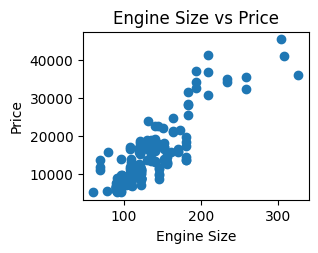

In [18]:
plt.subplot(2, 2, 1)
plt.scatter(df['engine-size'], df['price'])
plt.title('Engine Size vs Price')
plt.xlabel('Engine Size')
plt.ylabel('Price')

Text(0.5, 1.0, 'Horsepower vs Price (by Body Style)')

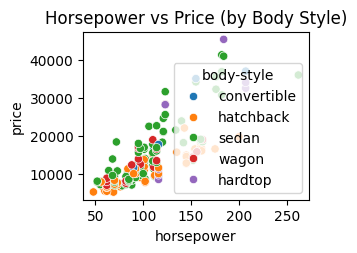

In [19]:
plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x='horsepower', y='price', hue='body-style')
plt.title('Horsepower vs Price (by Body Style)')

Text(0.5, 1.0, 'Distribution of Price')

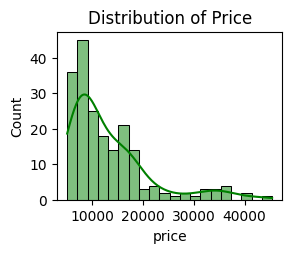

In [20]:
plt.subplot(2, 2, 3)
sns.histplot(df['price'], bins=20, kde=True, color='green')
plt.title('Distribution of Price')

Text(0.5, 1.0, 'Correlation Heatmap')

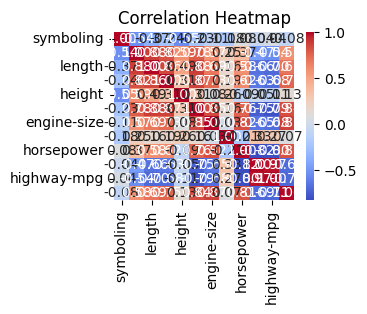

In [21]:
plt.subplot(2, 2, 4)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')

In [23]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>